In [19]:
"""LIBRERIAS Y DEPENDENCIAS"""
import pandas as pd
import numpy as np #trabaja con arrays
import matplotlib.pyplot as plt #parte grafica
import seaborn as sns #librería de visualización construida sobre Matplotlib y sirve para buscar correlaciones entre variables
import csv
import sqlite3


# from sklearn.model_selection import train_test_split #divide el dataset en train y test
# """NOTA IMPORTANTE, TENGO QUE DIVIDIR BIEN EL DATASET."""
# from sklearn.preprocessing import StandardScaler #estandariza las variables numéricas.
# """NOTA IMPORTANTE fit solamente sobre X_train."""
# from sklearn.ensemble import RandomForestClassifier #modelo basado en muchos árboles de decisión.
# from sklearn.linear_model import LogisticRegression
# from sklearn.neural_network import MLPClassifier
# #modelo avanzado de redes neuronales, que permite la clasificación de datos no lineales.

# from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_curve, auc, confusion_matrix
# #curva ROC: Permite analizar cómo cambia el comportamiento del modelo cuando modificás el umbral de decisión.
# #auc calcula el área bajo la curva ROC, que es una métrica de desempeño del modelo.
"""confusion_matrix util y usado en ciberseguridad
permite ver la cantidad de falsos positivos y falsos negativos que tiene el modelo, 
lo cual es muy importante en ciberseguridad, 
ya que un falso positivo puede generar alertas innecesarias y un falso negativo puede 
permitir que un ataque pase desapercibido."""

# from sklearn.preprocessing import label_binarize
# #Convierte etiquetas categóricas/multiclase en representación binaria.
# from itertools import cycle

"""FLUJO INICIAL PROBLABLE
Random Forest + Logistic Regression + SVM + MLP"""


'FLUJO INICIAL PROBLABLE\nRandom Forest + Logistic Regression + SVM + MLP'

In [20]:
"""CONEXIONES A LA BASE DE DATOS"""
df_ddos_2 = pd.read_csv ("/home/rhev/Analisis de datos/Trabajo-Final-Analisis-de-Datos-1/DDoSdata.csv")
print(df_ddos_2.head(3).T)
df_ddos_2["stime"] = pd.to_datetime(df_ddos_2["stime"], unit="s")

/tmp/ipykernel_1353/1426398508.py:2: DtypeWarning: Columns (0: sport, 1: dport) have mixed types. Specify dtype option on import or set low_memory=False.
  df_ddos_2 = pd.read_csv ("/home/rhev/Analisis de datos/Trabajo-Final-Analisis-de-Datos-1/DDoSdata.csv")


                                                 0                 1  \
Unnamed: 0                                 1650261           1650262   
pkSeqID                                    1650261           1650262   
stime                             1528102921.34461  1528102921.34521   
flgs                                             e                 e   
flgs_number                                      1                 1   
proto                                          tcp               tcp   
proto_number                                     1                 1   
saddr                              192.168.100.150   192.168.100.150   
sport                                        54110             54112   
daddr                                192.168.100.3     192.168.100.3   
dport                                           80                80   
pkts                                            10                10   
bytes                                         1729              

In [21]:
"""RENOMBRANDO COLUMNAS"""
df_ddos_2 = df_ddos_2.rename(columns={
    'pkSeqID': 'id',
    'stime': 'start_time',
    'flgs': 'flags',
    'flgs_number': 'flags_number',
    'proto': 'protocol',
    'proto_number': 'protocol_number',
    'saddr': 'source_address',
    'sport': 'source_port',
    'daddr': 'destination_address',
    'dport': 'destination_port',
    'pkts': 'flow_packets',
    'Itime': 'initial_time',
    'dur': 'duration',
    'Itime' : 'initial_time',
    #####################################################################
    'spkts' : 'source_packets',
    'dpkts' : 'destination_packets',
    #relacion entre source_packets y destination_packets es importante
    'sbytes' : 'source_bytes',
    'dbytes' : 'destination_bytes',
    #esta relacion es como la anterior, la alta frecuencia incial seguida por una baja secuencia
    #de respuesta indica un flujo anomalo de paquetes
    #'Rate' : cantidad de trafico / tiempo
    'srate' : 'source_rate',
    #la presencia de muchas fuentes con tasas elevadas puede ser una señal muy interesante.
    'drate' : 'destination_rate',
    #La diferencia entre ambas puede ser significativa.
    'N_IN_Conn_P_DstIP' : 'num_incoming.connection_per_destip',
    #número de conexiones entrantes asociadas a una IP de destino.
    #los ataques ddos se caracterizan por atacar una misma victina desde multiples IP
    'N_IN_Conn_P_SrcIP' : 'num_incoming.connection_per_sourceip',
    #una misma IP participando en muchas conexiones puede ser relevante.
    'TnP_PSrcIP' : 'total_packets_from_sourceip',
    #representa el total de paquetes asociado a una IP de origen y cuanto trafico genera una ip
    'TnP_PDstIP' : 'total_packets_from_destip',
    #lo mismo pero al inverso
    'TnP_PerProto' : 'total_packets_per_protocol',
    #cantidad total de paquetes asociados a ese protocolo. TCP, UDP, ICMP, etc.
    'TnP_Per_Dport' : 'total_packets_per_destination_port',
    #cantidad total de paquetes asociados a ese puerto de destino.
    'AR_P_Proto_P_Sport' : 'average_rate_per_protocol_per_sourceport',
    'AR_P_Proto_P_Dport' : 'average_rate_per_protocol_per_destinationport',
    'Pkts_P_State_P_Protocol_P_DestIP' : 'pks_per_state_per_protocol_per_destip',
    'Pkts_P_State_P_Protocol_P_SrcIP' : 'pks_per_state_per_protocol_per_sourceip',
})   
df_ddos_2.columns

Index(['Unnamed: 0', 'id', 'start_time', 'flags', 'flags_number', 'protocol',
       'protocol_number', 'source_address', 'source_port',
       'destination_address', 'destination_port', 'flow_packets', 'bytes',
       'state', 'state_number', 'ltime', 'seq', 'duration', 'mean', 'stddev',
       'sum', 'min', 'max', 'source_packets', 'destination_packets',
       'source_bytes', 'destination_bytes', 'rate', 'source_rate',
       'destination_rate', 'TnBPSrcIP', 'TnBPDstIP',
       'total_packets_from_sourceip', 'total_packets_from_destip',
       'total_packets_per_protocol', 'total_packets_per_destination_port',
       'AR_P_Proto_P_SrcIP', 'AR_P_Proto_P_DstIP',
       'num_incoming.connection_per_destip',
       'num_incoming.connection_per_sourceip',
       'average_rate_per_protocol_per_sourceport',
       'average_rate_per_protocol_per_destinationport',
       'pks_per_state_per_protocol_per_destip',
       'pks_per_state_per_protocol_per_sourceip', 'attack', 'category',
       's

In [22]:
"""ANALISIS INICIAL DE DATOS"""

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)


print("Información del dataset:")
# display(df_ddos_2.shape)
# display(df_ddos_2.info())

# print("Descripción estadística del dataset:")
# display(df_ddos_2.describe())

print("Primeras 5 filas del dataset:")
display(df_ddos_2.head(100))

# print("Últimas 5 filas del dataset:")
# display(df_ddos_2.tail(5))

# print("Tipos de datos del dataset:")
# print(df_ddos_2.dtypes)

# print("Nombres de las columnas del dataset:")
# display(df_ddos_2.columns)


Información del dataset:
Primeras 5 filas del dataset:


,Unnamed: 0,id,start_time,flags,flags_number,protocol,protocol_number,source_address,source_port,destination_address,destination_port,flow_packets,bytes,state,state_number,ltime,seq,duration,mean,stddev,sum,min,max,source_packets,destination_packets,source_bytes,destination_bytes,rate,source_rate,destination_rate,TnBPSrcIP,TnBPDstIP,total_packets_from_sourceip,total_packets_from_destip,total_packets_per_protocol,total_packets_per_destination_port,AR_P_Proto_P_SrcIP,AR_P_Proto_P_DstIP,num_incoming.connection_per_destip,num_incoming.connection_per_sourceip,average_rate_per_protocol_per_sourceport,average_rate_per_protocol_per_destinationport,pks_per_state_per_protocol_per_destip,pks_per_state_per_protocol_per_sourceip,attack,category,subcategory
0,1650261,1650261,2018-06-04 09:02:01.344609976,e,1,tcp,1,192.168.100.150,54110,192.168.100.3,80,10,1729,RST,1,1.528103e+09,20,6.406424,0.679473,0.544126,1.358946,0.135347,1.223599,6,4,963,766,1.404840,0.780467,0.468280,56864,59969,308,328,328,700,1.268890,1.216620,40,38,1.560930,1.216620,328,308,1,DDoS,HTTP
1,1650262,1650262,2018-06-04 09:02:01.345210075,e,1,tcp,1,192.168.100.150,54112,192.168.100.3,80,10,1604,RST,1,1.528103e+09,21,6.405851,0.679572,0.544197,1.359144,0.135375,1.223769,6,4,838,766,1.404966,0.780536,0.468322,56864,59969,308,328,328,700,1.268890,1.216620,40,38,1.561070,1.216620,328,308,1,DDoS,HTTP
2,1650263,1650263,2018-06-04 09:02:01.350049973,e,1,tcp,1,192.168.100.150,54114,192.168.100.3,80,8,1708,RST,1,1.528103e+09,22,6.401038,1.110847,1.110847,2.221694,0.000000,2.221694,5,3,1008,700,1.093573,0.624899,0.900214,56864,59969,308,328,328,700,1.268890,1.216620,40,38,1.249800,1.216620,328,308,1,DDoS,HTTP
3,1650264,1650264,2018-06-04 09:02:01.350409985,e,1,tcp,1,192.168.100.150,54116,192.168.100.3,80,8,1462,RST,1,1.528103e+09,23,6.400703,1.113328,1.113328,2.226655,0.000000,2.226655,5,3,762,700,1.093630,0.624931,0.898208,56864,59969,308,328,328,700,1.268890,1.216620,40,38,1.249860,1.216620,328,308,1,DDoS,HTTP
4,1650265,1650265,2018-06-04 09:02:01.350659847,e,1,tcp,1,192.168.100.150,54118,192.168.100.3,80,8,1296,RST,1,1.528103e+09,24,6.400472,1.113098,1.113098,2.226195,0.000000,2.226195,5,3,596,700,1.093669,0.624954,0.898394,56864,59969,308,328,328,700,1.268890,1.216620,40,38,1.249910,1.216620,328,308,1,DDoS,HTTP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,1650356,1650356,2018-06-04 09:02:01.406919956,e,1,tcp,1,192.168.100.149,41782,192.168.100.3,80,10,1596,RST,1,1.528103e+09,147,13.404515,0.660976,0.934704,1.982927,0.000000,1.982847,6,4,830,766,0.671416,0.373009,0.262659,76221,175718,467,1016,1016,1016,0.757028,0.898047,100,46,0.746017,0.898047,1016,467,1,DDoS,HTTP
96,1650357,1650357,2018-06-04 09:02:01.407140017,e s,2,tcp,1,192.168.100.149,41784,192.168.100.3,80,15,3720,RST,1,1.528103e+09,148,13.404319,1.777493,1.375160,5.332478,0.000000,3.349605,11,4,2954,766,1.044440,0.746028,0.262664,76221,175718,467,1016,1016,1016,0.757028,0.898047,100,46,1.119040,0.898047,1016,467,1,DDoS,HTTP
97,1650358,1650358,2018-06-04 09:02:01.407370090,e s,2,tcp,1,192.168.100.149,41786,192.168.100.3,80,11,1882,RST,1,1.528103e+09,149,13.404093,0.729427,0.890276,2.188281,0.000000,1.982870,7,4,1116,766,0.746041,0.447624,0.262669,76221,175718,467,1016,1016,1016,0.757028,0.898047,100,46,0.820645,0.898047,1016,467,1,DDoS,HTTP
98,1650359,1650359,2018-06-04 09:02:01.407590151,e s,2,tcp,1,192.168.100.149,41788,192.168.100.3,80,11,1623,RST,1,1.528103e+09,150,13.403892,1.014394,1.424588,3.043182,0.000304,3.029050,8,3,923,700,0.746052,0.522236,0.326859,76221,175718,467,1016,1016,1016,0.757028,0.898047,100,46,0.820657,0.898047,1016,467,1,DDoS,HTTP


Observaciones Iniciales:
1) El dataset proviene de Kaggle, especificamente https://www.kaggle.com/datasets/siddharthm1698/ddos-botnet-attack-on-iot-devices.
2) Cuenta con 1.927.101 registros distribuidos en 




1) 192.168.100.150, en los primeros 20 registros ataca desde 20 puertos distintos, en los 100 registros
   posteriores se observan 3 IP's distintas pertenecientes a la misma subred.
2) La IP objetivo es la misma en los 20 primeros casos, 192.168.100.3.
3) El puerto objetivo es el n°80, puerto estandar de las conexiones HTTP sin cifrar.
4) Las primeras 20 son emitidas y recibidas al mismo tiempo.
4) El promedio de bytes emitidos y reenviados es de 1300 aproximados.
5) El agrupamiento por protocolo y el agrupamiento por puerto de destino están capturando cantidades diferentes de tráfico.





In [23]:
"""Limpieza dataset ddos_2 basado en el video de
https://www.youtube.com/watch?v=QqEdSk98Wqs KNOWLEDGE DOCTOR"""
print("Dimensiones:", df_ddos_2.shape) #Dimensiones: (1927101, 49)

print("\nTipos de datos:")
print(df_ddos_2.dtypes)

print("\nValores nulos:") #sin valores nulos.
print(df_ddos_2.isnull().sum())

print("\nDuplicados:") #sin duplicados.
print(df_ddos_2.duplicated().sum())

# print("\nValores únicos:") #1927101
# print(df_ddos_2.nunique().sort_values())

# print(df_ddos_2["destination_port"].duplicated().sum())
# #aunque no hay duplicados, si hay muchos valores repetidos en la columna destination_port, lo cual puede afectar el modelo.

# print("\nColumnas:")
# df_ddos_2.columns

# print("Se mostrara graficamente la cantidad de valores nulos por columna del dataset ddos_2")
# def Missingvalues(df_ddos_2):
#     missing_values = df_ddos_2.isnull().sum()
#     fig = plt.figure(figsize=(8, 1))
#     missing_values.plot(kind='bar')
#     plt.title("Missing Values per Column")
#     plt.xlabel("Columns")
#     plt.ylabel("Total Number of Missing Values")
#     plt.show()

# Missingvalues(df_ddos_2)

Dimensiones: (1927101, 47)

Tipos de datos:
Unnamed: 0                                                int64
id                                                        int64
start_time                                       datetime64[ns]
flags                                                       str
flags_number                                              int64
protocol                                                    str
protocol_number                                           int64
source_address                                              str
source_port                                              object
destination_address                                         str
destination_port                                         object
flow_packets                                              int64
bytes                                                     int64
state                                                       str
state_number                                              in

Observaciones de la limpieza:

1) No tenemos valores nulos, pero la repeticion de valores como por ejemplo los puerto (80) pueden alterar 
   la capacidad de reconocimiento de patrones del Machine Learning.
   Su eliminacion por otra parte, tampoco es conveniente al ser una etiqueta fundamental del ataque ddos.
2) Tampoco tenemos que preocuparnos por una identacion inicial entre columnas que alteren el flujo de datos.

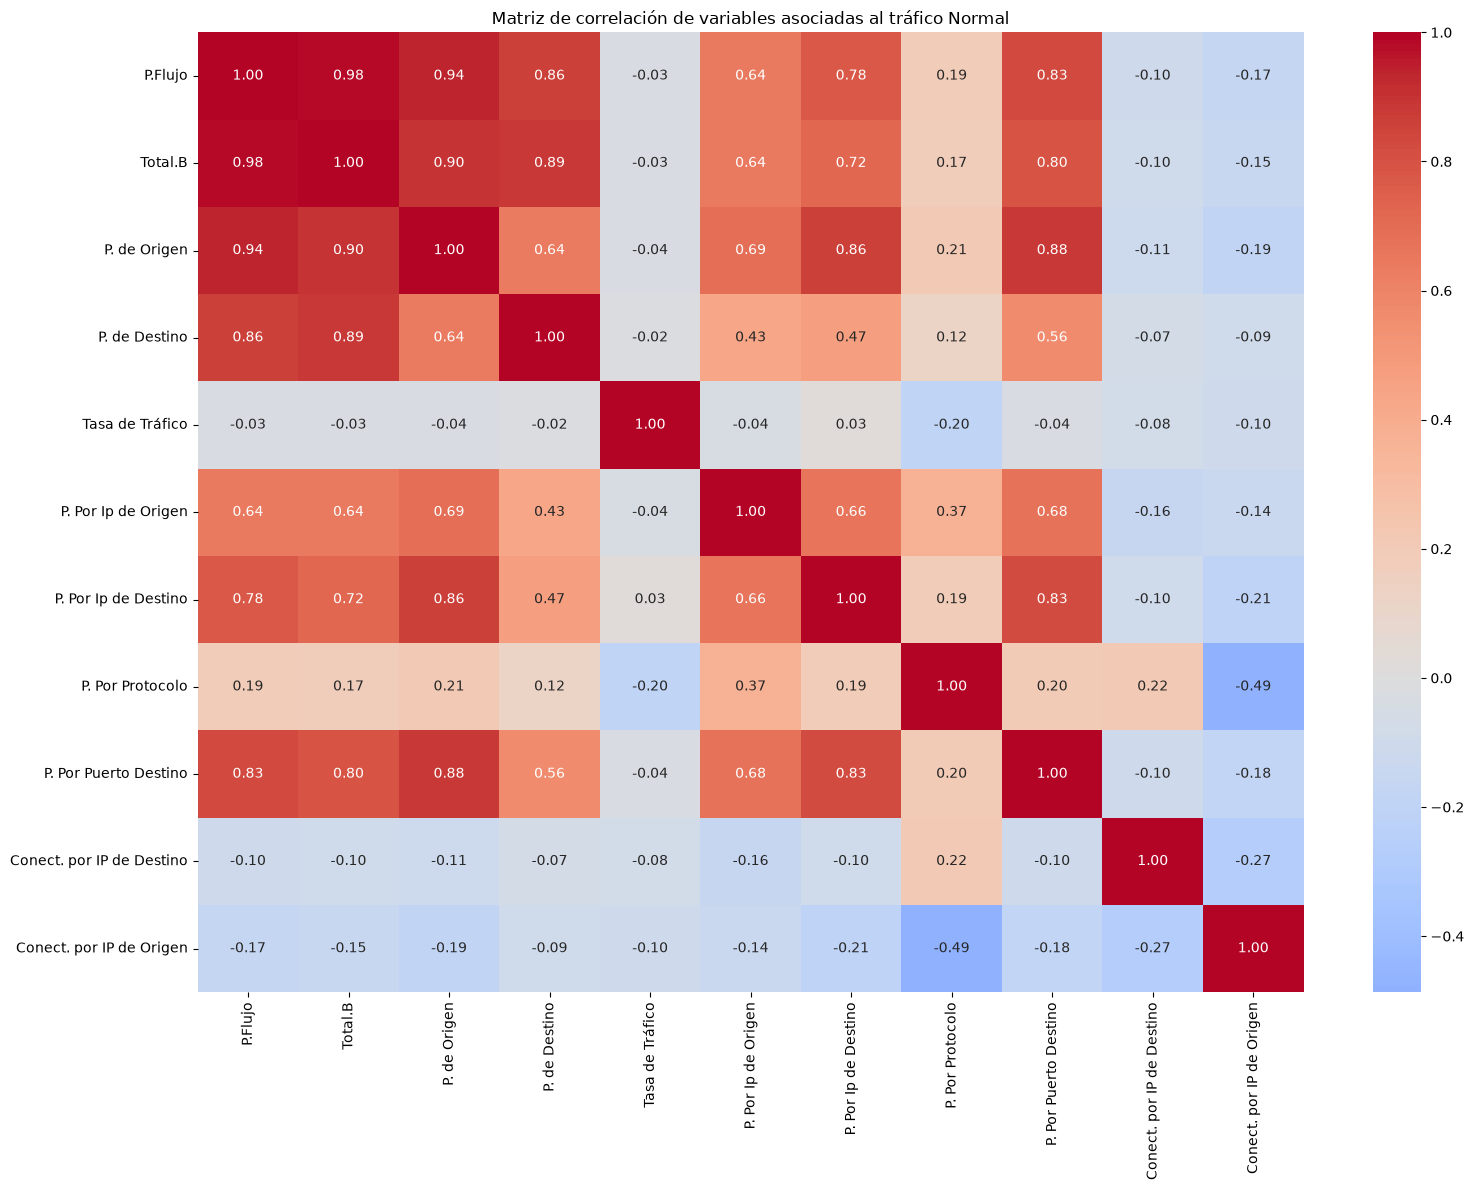

In [24]:
# FILTRAR ÚNICAMENTE EL TRÁFICO NORMAL
df_normal = df_ddos_2[df_ddos_2["category"] == "Normal"].copy()

# VARIABLES A UTILIZAR EN LA CORRELACIÓN
variables_correlacion = [
    "flow_packets",
    "bytes",
    "source_packets",
    "destination_packets",
    "rate",
    "total_packets_from_sourceip",
    "total_packets_from_destip",
    "total_packets_per_protocol",
    "total_packets_per_destination_port",
    "num_incoming.connection_per_destip",
    "num_incoming.connection_per_sourceip",
]

# NOMBRES MÁS LEGIBLES PARA LA MATRIZ
nombres_legibles = {
    "flow_packets": "P.Flujo",
    "bytes": "Total.B",
    "source_packets": "P. de Origen",
    "destination_packets": "P. de Destino",

    "rate": "Tasa de Tráfico",

    "total_packets_from_sourceip": "P. Por Ip de Origen",
    "total_packets_from_destip": "P. Por Ip de Destino",

    "total_packets_per_protocol": "P. Por Protocolo",
    "total_packets_per_destination_port": "P. Por Puerto Destino",

    "num_incoming.connection_per_destip": "Conect. por IP de Destino",
    "num_incoming.connection_per_sourceip": "Conect. por IP de Origen",
}

# MATRIZ DE CORRELACIÓN DEL TRÁFICO NORMAL
matriz_correlacion_normal = df_normal[variables_correlacion].corr()

# CAMBIAR LOS NOMBRES DE LAS FILAS Y COLUMNAS DE LA MATRIZ DE CORRELACIÓN
matriz_correlacion_normal = matriz_correlacion_normal.rename(
    index=nombres_legibles,
    columns=nombres_legibles
)
# display(matriz_correlacion_normal)

# GRAFICAR
plt.figure(figsize=(16, 12))
sns.heatmap(
    matriz_correlacion_normal,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title(
    "Matriz de correlación de variables asociadas al tráfico Normal"
)
plt.tight_layout()

#esto lo pude haber hecho con un bucle for, pero lo hice a mano para que quede más legible.
#me arrepiento

# GUARDAR EN SVG
plt.savefig(
    "matriz_correlacion_normal.svg",
    format="svg",
    bbox_inches="tight"
)
plt.show()

Se mostrara graficamente la cantidad de puertos de destino y la cantidad de paquetes asociados a cada uno del dataset ddos_2


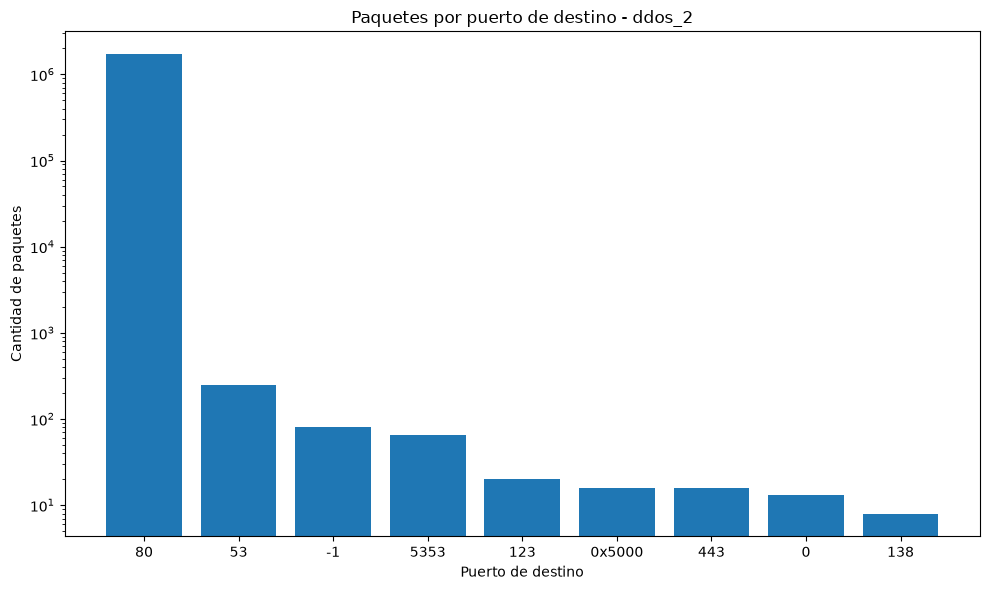

In [25]:
"""GRAFICO DE PUERTOS DE DESTINO Y CANTIDAD DE PAQUETES ASOCIADOS A CADA UNO DEL DATASET ddos_2"""
df_puertos = df_ddos_2.groupby("destination_port").size().reset_index(name="count")
# print(df_puertos.head(10))

print("Se mostrara graficamente la cantidad de puertos de destino y la cantidad de paquetes asociados a cada uno del dataset ddos_2")

top_n = df_puertos.sort_values("count", ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.bar(top_n["destination_port"].astype(str), top_n["count"])
plt.yscale("log")  # escala log por la dominancia del puerto 80
plt.xlabel("Puerto de destino")
plt.ylabel("Cantidad de paquetes")
plt.title("Paquetes por puerto de destino - ddos_2")
plt.tight_layout()

# GUARDAR EN SVG
plt.savefig(
    "escala_paquetes_por_puerto.svg",
    format="svg",
    bbox_inches="tight"
)
plt.show()



In [26]:
"""¿Cuántas IPs distintas atacan a la víctima?"""
ips_atacantes = df_ddos_2[df_ddos_2["destination_address"] == "192.168.100.3"]["source_address"].nunique()
print(f"Cantidad de IPs atacantes distintas: {ips_atacantes}")

print(df_ddos_2[df_ddos_2["destination_address"] == "192.168.100.3"]["source_address"].value_counts())

Cantidad de IPs atacantes distintas: 9
source_address
192.168.100.147    519964
192.168.100.148    494639
192.168.100.150    456942
192.168.100.149    451593
192.168.100.5           7
192.168.100.6           5
192.168.100.7           5
192.168.100.1           4
192.168.100.55          3
Name: count, dtype: int64


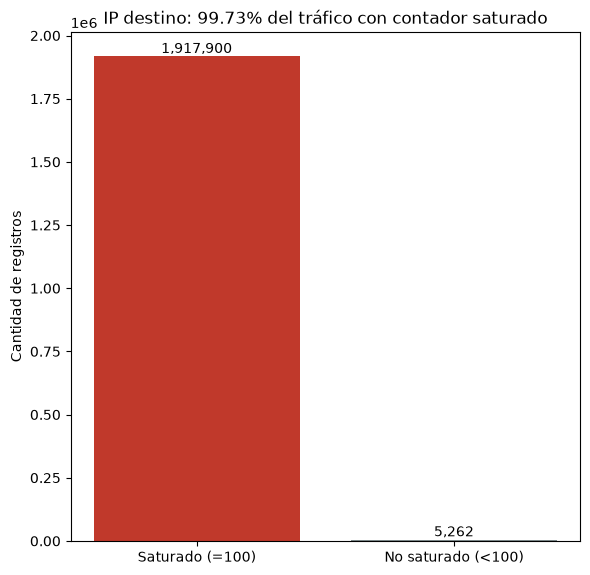

In [27]:
"""Saturación del contador de conexiones entrantes por IP destino"""
saturado = (df_ataque["num_incoming.connection_per_destip"] == 100).sum()
no_saturado = len(df_ataque) - saturado
pct_saturado = saturado / len(df_ataque) * 100

plt.figure(figsize=(6, 6))
plt.bar(
    ["Saturado (=100)", "No saturado (<100)"],
    [saturado, no_saturado],
    color=["#c0392b", "#7f8c8d"])

plt.ylabel("Cantidad de registros")
plt.title(f"IP destino: {pct_saturado:.2f}% del tráfico con contador saturado")

# Etiquetas con el valor exacto sobre cada barra
for i, v in enumerate([saturado, no_saturado]):
    plt.text(i, v, f"{v:,}", ha="center", va="bottom")

plt.tight_layout()
plt.savefig("saturacion_destip.svg", format="svg", bbox_inches="tight")
plt.show()



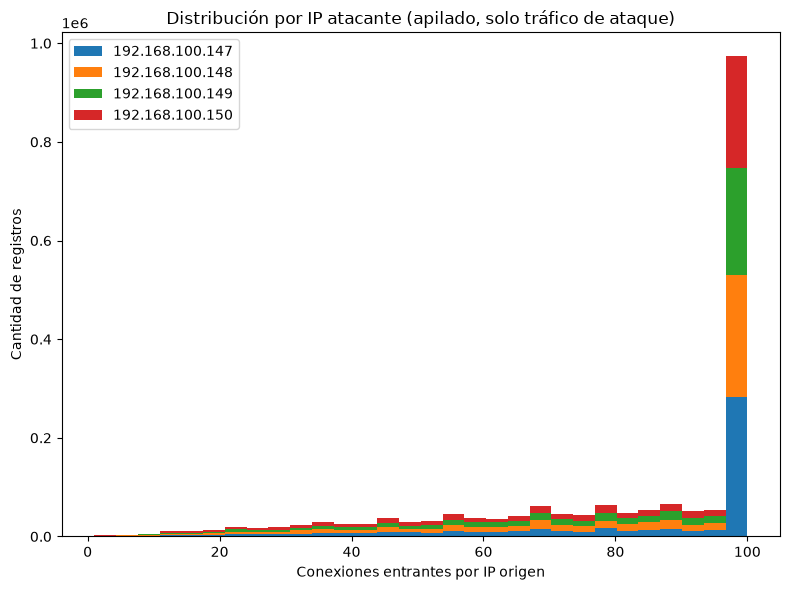

In [28]:
"""Distribución por IP atacante, apilado y sin tráfico normal"""
ips_atacantes = ["192.168.100.147", "192.168.100.148", "192.168.100.149", "192.168.100.150"]
df_atacantes = df_ataque[df_ataque["source_address"].isin(ips_atacantes)]

plt.figure(figsize=(8, 6))
plt.hist(
    [df_atacantes[df_atacantes["source_address"] == ip]["num_incoming.connection_per_sourceip"] for ip in ips_atacantes],
    bins=30, stacked=True, label=ips_atacantes
)
plt.xlabel("Conexiones entrantes por IP origen")
plt.ylabel("Cantidad de registros")
plt.title("Distribución por IP atacante (apilado, solo tráfico de ataque)")
plt.legend()
plt.tight_layout()
plt.savefig("distribucion_apilada_atacantes.svg", format="svg", bbox_inches="tight")
plt.show()

BIBLIOGRAFIA:

What are Protocol Packets and Byte Counts? -. https://www.cbtnuggets.com/blog/technology/networking/understanding-protocol-packets-and-byte-counts

Project 74 : DDoS Attack Classification using Machine Learning-.https://www.youtube.com/watch?v=QqEdSk98Wqs

DDoS Dataset by Devendra -. https://www.kaggle.com/datasets/devendra416/ddos-datasets

DDoS Dataset by SIDDHARTH M -.https://www.kaggle.com/datasets/siddharthm1698/ddos-botnet-attack-on-iot-devices y https://github.com/Chando0185/Multiverse_of_100-_data_science_project_series/blob/main/DDos%20Attack/DDOS%20Attack%20Classification%20Using%20Machine%20Learning.ipynb

Documentacion sobre el ARP (RFC-826) -. https://www.rfc-editor.org/rfc/rfc826.html?utm_source=chatgpt.com